In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
task_data = pd.read_csv("output.csv").set_index("userID")
task_data = task_data.replace({"started but not completed": float("nan"), "not started": float("nan"), "not completed": float("nan")})
task_data["taskTime1"] = pd.to_numeric(task_data["taskTime1"])
task_data["taskTime2"] = pd.to_numeric(task_data["taskTime2"])
task_data["taskTime3"] = pd.to_numeric(task_data["taskTime3"])
task_data

,time,interface,task1,task2,task3,taskStart1,taskStart2,taskStart3,taskEnd1,taskEnd2,...,taskAnswer1,taskAnswer2,taskAnswer3,delete,taskTime1,taskTime2,taskTime3,correct1,correct2,correct3
userID,,,,,,,,,,,,,,,,,,,,,
1,1.717380e+12,control,where,convolve,minmax,1.717380e+12,1.717380e+12,1.717380e+12,1.717380e+12,1.717380e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1051224,682921,363797,True,True,True
5,1.717880e+12,control,where,convolve,minmax,1.717880e+12,1.717880e+12,1.717880e+12,1.717880e+12,1.717880e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,219232,533099,73411,True,True,True
7,1.717980e+12,control,where,convolve,minmax,1.717980e+12,1.717980e+12,1.717980e+12,1.717980e+12,1.717980e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1149223,564988,150678,True,True,True
9,1.718130e+12,control,where,convolve,minmax,1.718130e+12,1.718130e+12,1.718130e+12,1.718130e+12,1.718130e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1878641,2099530,193677,True,True,True
11,1.718140e+12,control,where,convolve,minmax,1.718140e+12,1.718140e+12,1.718140e+12,1.718140e+12,1.718140e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1154406,1003275,207278,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,1.725400e+12,sequence,where,convolve,minmax,1.725400e+12,1.725400e+12,1.725400e+12,1.725400e+12,1.725400e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,966279,406914,173709,False,True,True
112,1.725400e+12,sequence,where,convolve,minmax,1.725400e+12,1.725400e+12,1.725400e+12,1.725400e+12,1.725400e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nk = tf.constan...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1205579,600323,165741,True,True,True
113,1.725410e+12,sequence,where,convolve,minmax,1.725410e+12,1.725410e+12,1.725410e+12,1.725410e+12,1.725410e+12,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1094124,757488,488030,False,True,True


In [3]:
task_data.groupby("interface")[["taskTime1", "taskTime2", "taskTime3"]].mean()

,taskTime1,taskTime2,taskTime3
interface,,,
canonicalization,5.051264e+05,1.083441e+06,718363.000000
control,1.056025e+06,8.978740e+05,256116.214286
llmBasic,6.621906e+05,5.479897e+05,285695.214286
llmTranslation,8.177788e+05,6.931721e+05,399280.285714
sequence,9.347568e+05,7.280606e+05,503593.714286
translation,1.200449e+06,9.817099e+05,646884.571429


In [4]:
survey = pd.read_csv("post-survey.csv")
survey = survey.rename(columns={survey.columns[1]: "userID", survey.columns[2]: "recruiting_source", survey.columns[3]: "self_est_prog_exp", survey.columns[4]: "yrs_prog_weekly", survey.columns[5]: "yrs_prog"})
survey = survey.replace({"<1 year": "0", "10 or more years": "10", "<1 year ago": "0", "10 or more years ago": "10"})
survey = survey.set_index("userID")
survey["self_est_prog_exp"] = pd.to_numeric(survey["self_est_prog_exp"])
survey["yrs_prog_weekly"] = pd.to_numeric(survey["yrs_prog_weekly"])
survey["yrs_prog"] = pd.to_numeric(survey["yrs_prog"])
survey

,Timestamp,recruiting_source,self_est_prog_exp,yrs_prog_weekly,yrs_prog,"Do you have experience with any programming languages or libraries that you felt were helpful for completing the programming tasks in TensorFlow? If so, please name them here.",You completed these program editing tasks using an online interface or tool. Do you have feedback about the tool? Was there anything about the tool that you found difficult to use? Any suggestions to improve the tool?,"If you have any other feedback regarding the study, please provide it here.","What is your occupation? If you are a student, what is your major?"
userID,,,,,,,,,
11,6/11/2024 14:24,Data 001 Ed,6,1,2,pandas/numpy kind of,NaN,NaN,NaN
12,6/11/2024 15:53,email on EdStem,7,3,3,PyTorch,I did help a bit to get an idea of what the te...,NaN,NaN
13,6/12/2024 10:03,Ed Forum,6,4,4,documentation,NaN,NaN,NaN
5,6/12/2024 12:27,On Ed,6,3,5,NaN,"Tool was good, maybe it should indicate when s...",NaN,NaN
4,6/12/2024 12:59,I came across it online(Reddit),8,5,6,"Yes, Python helped me understand the basic syntax",The tool was fine. The interface was plain and...,NaN,NaN
...,...,...,...,...,...,...,...,...,...
77,8/3/2024 19:34,email alert xlab,8,3,5,NaN,NaN,NaN,Software developer
78,8/4/2024 13:34,Xlab email,8,9,10,NaN,NaN,NaN,Ph.D. student in Electrical Engineering
79,8/9/2024 9:04,xlab website,5,1,2,NaN,NaN,NaN,Cognitive Science


In [5]:
participants = pd.read_csv("participants.csv").set_index("id")
participants

,start time,conducted by,group,exp,recruiting source,notes
id,,,,,,
1,NaN,Jacob,control,6,other,NaN
5,NaN,Jacob,control,6,other,NaN
7,NaN,Jacob,control,6,other,NaN
9,NaN,Jacob,control,4,other,NaN
11,NaN,Jacob,control,6,other,NaN
...,...,...,...,...,...,...
112,9/3/2024 3:00 PM,Laila,sequence,8,other,assign post-survey
113,9/3/2024 6:00 PM,Jacob,sequence,7,other,assign post-survey
114,9/3/2024 7:30 PM,Jacob,sequence,6,other,NaN


In [6]:
df = participants.merge(task_data, left_index=True, right_index=True)
df["interface"] = pd.Categorical(df["interface"], ["control", "llmBasic", "translation", "llmTranslation", "canonicalization", "sequence", "highlighting"])
df

,start time,conducted by,group,exp,recruiting source,notes,time,interface,task1,task2,...,taskAnswer1,taskAnswer2,taskAnswer3,delete,taskTime1,taskTime2,taskTime3,correct1,correct2,correct3
1,NaN,Jacob,control,6,other,NaN,1.717380e+12,control,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1051224,682921,363797,True,True,True
5,NaN,Jacob,control,6,other,NaN,1.717880e+12,control,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,219232,533099,73411,True,True,True
7,NaN,Jacob,control,6,other,NaN,1.717980e+12,control,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1149223,564988,150678,True,True,True
9,NaN,Jacob,control,4,other,NaN,1.718130e+12,control,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1878641,2099530,193677,True,True,True
11,NaN,Jacob,control,6,other,NaN,1.718140e+12,control,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1154406,1003275,207278,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,9/3/2024 1:30 PM,Jacob,sequence,5,other,NaN,1.725400e+12,sequence,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,966279,406914,173709,False,True,True
112,9/3/2024 3:00 PM,Laila,sequence,8,other,assign post-survey,1.725400e+12,sequence,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nk = tf.constan...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1205579,600323,165741,True,True,True
113,9/3/2024 6:00 PM,Jacob,sequence,7,other,assign post-survey,1.725410e+12,sequence,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,1094124,757488,488030,False,True,True
114,9/3/2024 7:30 PM,Jacob,sequence,6,other,NaN,1.725420e+12,sequence,where,convolve,...,"x = tf.constant([5, 2, 20, 15, 32, 100])\nnew_...","x = tf.constant([4, 12, 8, 8])\nnew_x = tf.squ...","x = tf.constant(\n [[1, 2, 3],\n [101, 102, ...",False,587538,763534,577471,False,True,True


In [7]:
df.columns

Index(['start time', 'conducted by', 'group', 'exp', 'recruiting source',
       'notes', 'time', 'interface', 'task1', 'task2', 'task3', 'taskStart1',
       'taskStart2', 'taskStart3', 'taskEnd1', 'taskEnd2', 'taskEnd3',
       'timesRan1', 'timesRan2', 'timesRan3', 'timesUsed1', 'timesUsed2',
       'timesUsed3', 'taskCompletion1', 'taskCompletion2', 'taskCompletion3',
       'taskAnswer1', 'taskAnswer2', 'taskAnswer3', 'delete', 'taskTime1',
       'taskTime2', 'taskTime3', 'correct1', 'correct2', 'correct3'],
      dtype='object')

In [8]:
df["interface"].value_counts()

interface
control             14
llmBasic            14
translation         14
llmTranslation      14
sequence            14
canonicalization    13
highlighting         0
Name: count, dtype: int64

In [9]:
df[["taskCompletion1", "taskCompletion2", "taskCompletion3"]]

,taskCompletion1,taskCompletion2,taskCompletion3
1,answered,answered,answered
5,answered,answered,answered
7,answered,answered,answered
9,answered,answered,answered
11,answered,answered,answered
...,...,...,...
111,answered,answered,answered
112,answered,answered,answered
113,answered,answered,answered
114,answered,answered,answered


In [10]:
a = pd.melt(df, id_vars=["interface"], value_vars=["taskTime1", "taskTime2", "taskTime3"]).rename(columns={"value":"time"})
b = pd.melt(df, id_vars=["interface"], value_vars=["taskCompletion1", "taskCompletion2", "taskCompletion3"])[["value"]].rename(columns={"value":"answered"})
c = pd.melt(df, id_vars=["interface"], value_vars=["timesRan1", "timesRan2", "timesRan3"])[["value"]].rename(columns={"value": "times ran"})
d = pd.melt(df, id_vars=["interface"], value_vars=["correct1", "correct2", "correct3"])[["value"]].rename(columns={"value": "correct?"})
by_task = pd.merge(a, b, left_index=True, right_index=True).merge(c, left_index=True, right_index=True).merge(d, left_index=True, right_index=True).rename(columns={"variable":"task"})
by_task["task"] = by_task["task"].str[-1]
by_task["time"] = pd.to_numeric(by_task["time"])
by_task["time (minutes)"] = by_task["time"]/60000
by_task

,interface,task,time,answered,times ran,correct?,time (minutes)
0,control,1,1051224,answered,22.0,True,17.520400
1,control,1,219232,answered,16.0,True,3.653867
2,control,1,1149223,answered,38.0,True,19.153717
3,control,1,1878641,answered,12.0,True,31.310683
4,control,1,1154406,answered,35.0,True,19.240100
...,...,...,...,...,...,...,...
244,sequence,3,173709,answered,5.0,True,2.895150
245,sequence,3,165741,answered,7.0,True,2.762350
246,sequence,3,488030,answered,15.0,True,8.133833
247,sequence,3,577471,answered,5.0,True,9.624517


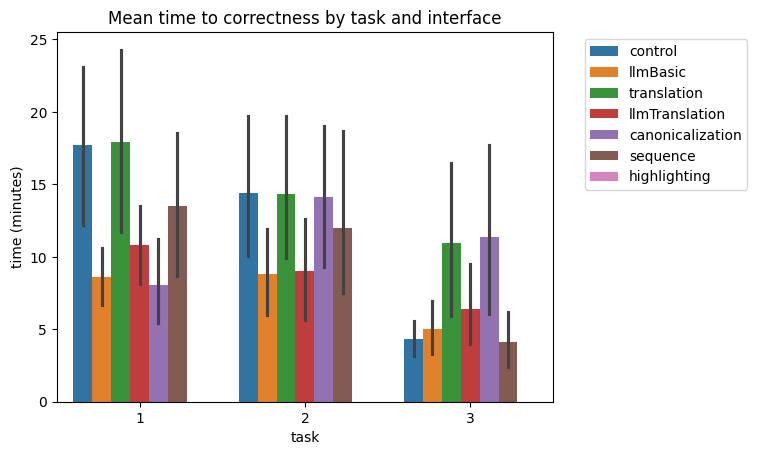

In [12]:
sns.barplot(by_task[by_task["correct?"] == True], x="task", y="time (minutes)", hue="interface")
plt.title("Mean time to correctness by task and interface")
plt.legend(bbox_to_anchor=(1.05, 1.0))

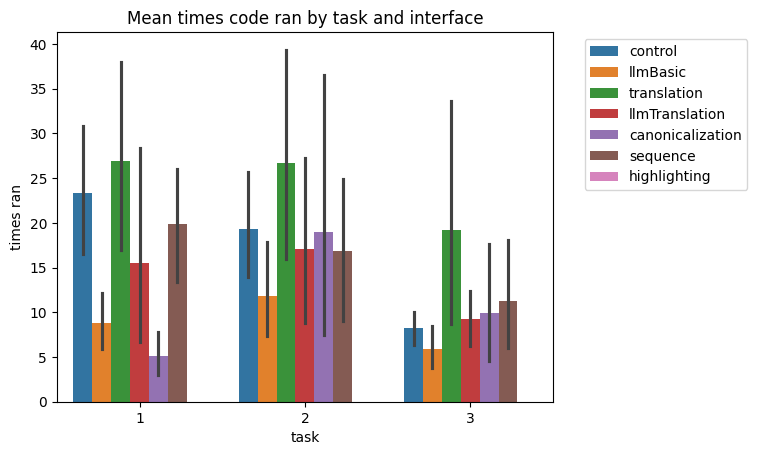

In [13]:
sns.barplot(by_task, x="task", y="times ran", hue="interface")
plt.title("Mean times code ran by task and interface")
plt.legend(bbox_to_anchor=(1.05, 1.0))

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\221120875.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perc_correct = by_task.groupby(["task", "interface"])[["correct?"]].agg(lambda x: np.sum(x) / len(x)).reset_index().rename(columns={"correct?": "% correct"})


Text(0.5, 1.0, 'Percentage of participants answering correctly by task and interface')

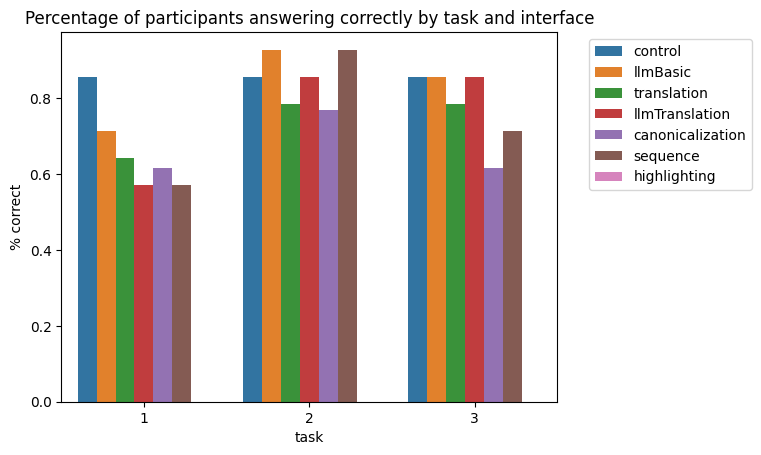

In [14]:
perc_correct = by_task.groupby(["task", "interface"])[["correct?"]].agg(lambda x: np.sum(x) / len(x)).reset_index().rename(columns={"correct?": "% correct"})
sns.barplot(perc_correct, x="task", y="% correct", hue="interface")
plt.legend(bbox_to_anchor=(1.05, 1.0))
plt.title("Percentage of participants answering correctly by task and interface")

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\365820288.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perc_skipped = by_task.groupby(["task", "interface"])[["answered"]].agg(lambda x: np.sum([x == "skipped"]) / len(x)).reset_index().rename(columns={"answered": "% skipped"})


Text(0.5, 1.0, 'Percentage of participants who skipped by task and interface')

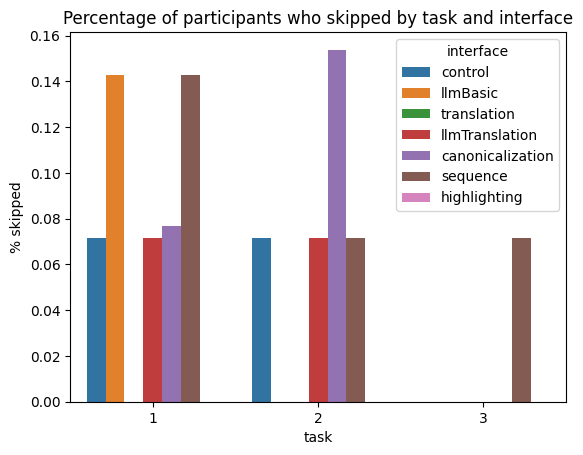

In [15]:
perc_skipped = by_task.groupby(["task", "interface"])[["answered"]].agg(lambda x: np.sum([x == "skipped"]) / len(x)).reset_index().rename(columns={"answered": "% skipped"})
sns.barplot(perc_skipped, x="task", y="% skipped", hue="interface")
plt.title("Percentage of participants who skipped by task and interface")

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\3512475423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perc_submitted_incorrectly = by_task[by_task["answered"] == "answered"].groupby(["task", "interface"])[["correct?"]].agg(lambda x: np.sum([x == False]) / len(x)).reset_index().rename(columns={"correct?": "% submitting incorrect answers"})


Text(0.5, 1.0, 'Percentage of participants who submitted incorrect answers by task and interface')

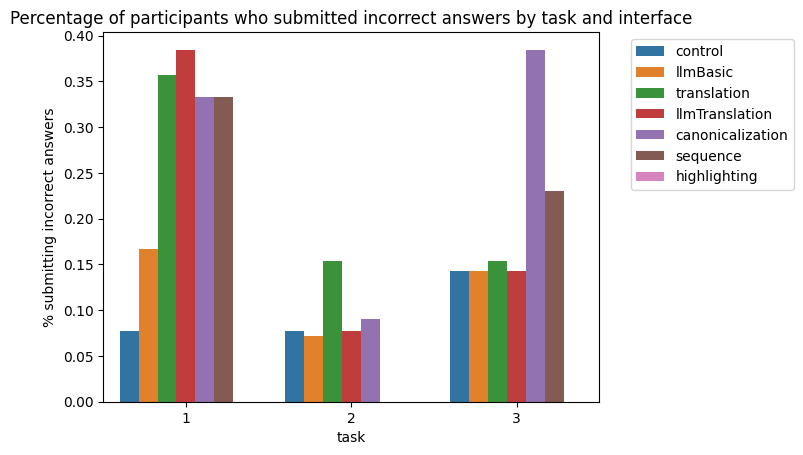

In [16]:
perc_submitted_incorrectly = by_task[by_task["answered"] == "answered"].groupby(["task", "interface"])[["correct?"]].agg(lambda x: np.sum([x == False]) / len(x)).reset_index().rename(columns={"correct?": "% submitting incorrect answers"})
sns.barplot(perc_submitted_incorrectly, x="task", y="% submitting incorrect answers", hue="interface")
plt.legend(bbox_to_anchor=(1.05, 1.0))
plt.title("Percentage of participants who submitted incorrect answers by task and interface")

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\1675088225.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perc_timed_out = by_task.groupby(["task", "interface"])[["answered"]].agg(lambda x: np.sum(x.isna()) / len(x)).reset_index().rename(columns={"answered": "% timed out"})


Text(0.5, 1.0, 'Percentage of participants who timed out by task and interface')

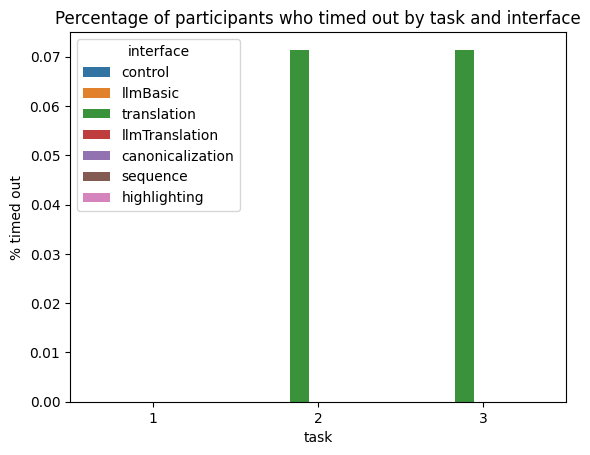

In [17]:
perc_timed_out = by_task.groupby(["task", "interface"])[["answered"]].agg(lambda x: np.sum(x.isna()) / len(x)).reset_index().rename(columns={"answered": "% timed out"})
sns.barplot(perc_timed_out, x="task", y="% timed out", hue="interface")
plt.title("Percentage of participants who timed out by task and interface")

In [18]:
by_task_answered = by_task[by_task["answered"]=="answered"]
by_task_answered

,interface,task,time,answered,times ran,correct?,time (minutes)
0,control,1,1051224,answered,22.0,True,17.520400
1,control,1,219232,answered,16.0,True,3.653867
2,control,1,1149223,answered,38.0,True,19.153717
3,control,1,1878641,answered,12.0,True,31.310683
4,control,1,1154406,answered,35.0,True,19.240100
...,...,...,...,...,...,...,...
244,sequence,3,173709,answered,5.0,True,2.895150
245,sequence,3,165741,answered,7.0,True,2.762350
246,sequence,3,488030,answered,15.0,True,8.133833
247,sequence,3,577471,answered,5.0,True,9.624517


In [19]:
by_task_answered_grouped = by_task_answered[["task", "interface", "time (minutes)", "times ran"]].groupby(["task", "interface"]).mean().reset_index()
by_task_answered_grouped

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\3509043700.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_task_answered_grouped = by_task_answered[["task", "interface", "time (minutes)", "times ran"]].groupby(["task", "interface"]).mean().reset_index()


,task,interface,time (minutes),times ran
0,1,control,17.438617,22.923077
1,1,llmBasic,8.632140,7.666667
2,1,translation,20.007489,26.928571
3,1,llmTranslation,12.243119,9.538462
4,1,canonicalization,8.383403,5.416667
5,1,sequence,14.022989,19.416667
6,1,highlighting,NaN,NaN
7,2,control,15.268764,20.307692
8,2,llmBasic,9.133162,11.857143
9,2,translation,15.423126,27.692308


Text(0.5, 1.0, 'Mean time to completion by task and interface')

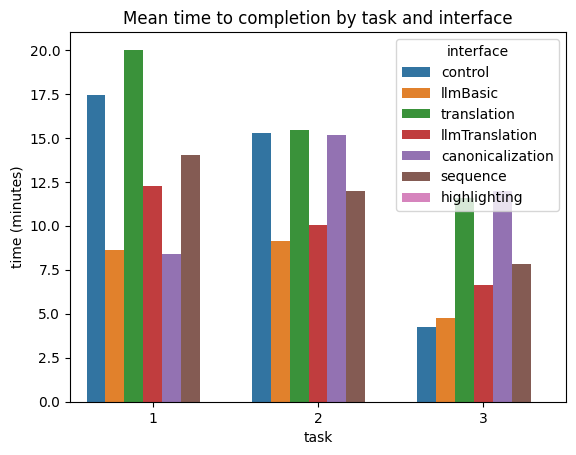

In [20]:
sns.barplot(by_task_answered_grouped, x="task", y="time (minutes)", hue="interface")
plt.title("Mean time to completion by task and interface")

Text(0.5, 1.0, 'Mean times code ran by task and interface')

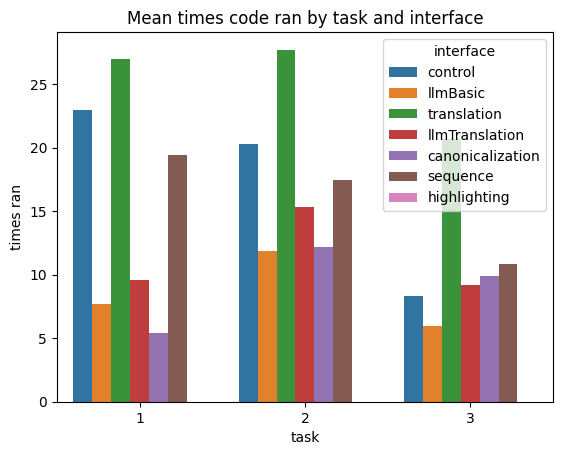

In [21]:
sns.barplot(by_task_answered_grouped, x="task", y="times ran", hue="interface")
plt.title("Mean times code ran by task and interface")

In [22]:
df.groupby("interface")[["timesRan1", "timesRan2", "timesRan3"]].mean()

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\2372294027.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("interface")[["timesRan1", "timesRan2", "timesRan3"]].mean()


,timesRan1,timesRan2,timesRan3
interface,,,
control,23.285714,19.357143,8.285714
llmBasic,8.857143,11.857143,5.928571
translation,26.928571,26.714286,19.214286
llmTranslation,15.500000,17.071429,9.214286
canonicalization,5.076923,19.000000,9.916667
sequence,19.857143,16.857143,11.285714
highlighting,NaN,NaN,NaN


<Axes: xlabel='task', ylabel='time (minutes)'>

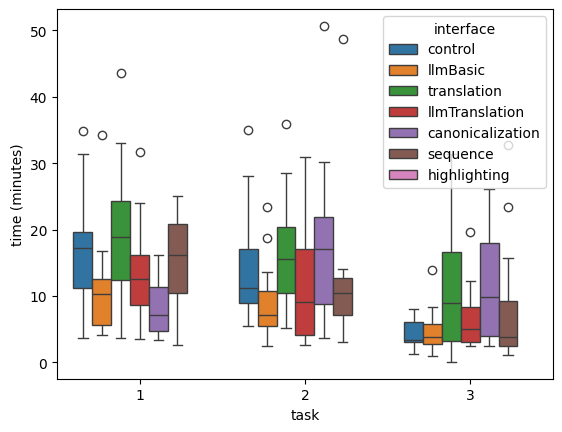

In [23]:
sns.boxplot(by_task, x="task", y="time (minutes)", hue="interface")

<Axes: xlabel='task', ylabel='time (minutes)'>

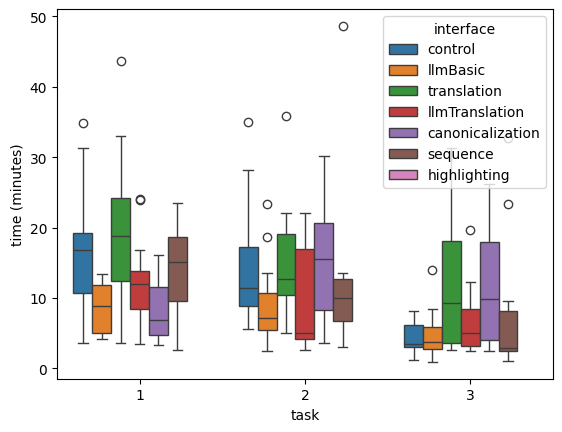

In [24]:
sns.boxplot(by_task_answered, x="task", y="time (minutes)", hue="interface")

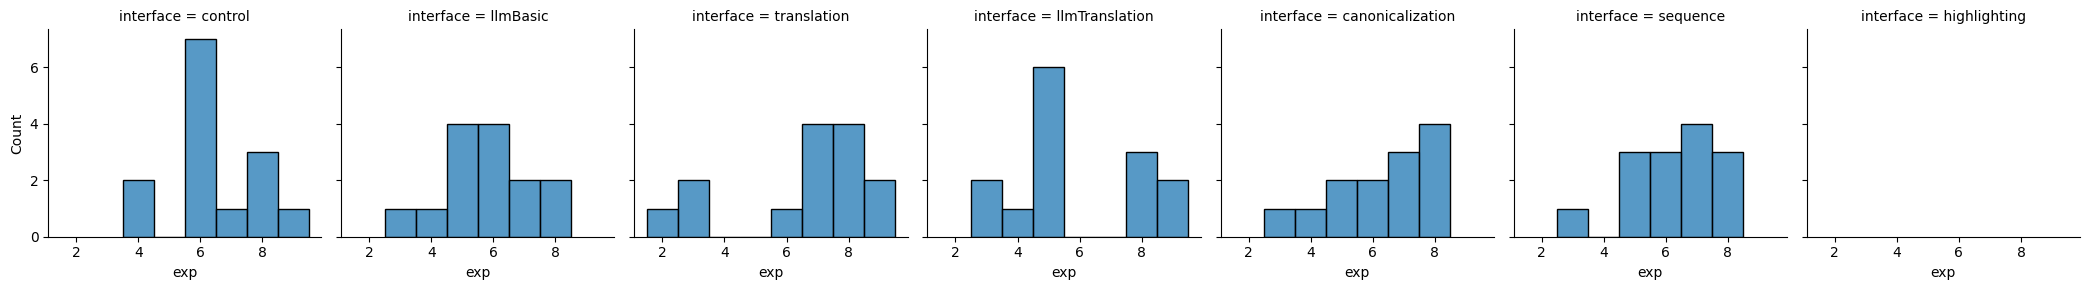

In [26]:
g = sns.FacetGrid(df, col="interface")
g.map(sns.histplot, "exp", binwidth=1, discrete=True)

In [27]:
df["interface"].value_counts()

interface
control             14
llmBasic            14
translation         14
llmTranslation      14
sequence            14
canonicalization    13
highlighting         0
Name: count, dtype: int64

In [28]:
df[["interface", "exp"]].groupby("interface").mean()[["exp"]]

C:\Users\jayim\AppData\Local\Temp\ipykernel_18120\1504278246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[["interface", "exp"]].groupby("interface").mean()[["exp"]]


,exp
interface,
control,6.428571
llmBasic,5.785714
translation,6.571429
llmTranslation,5.857143
canonicalization,6.307692
sequence,6.285714
highlighting,NaN
